<a href="https://colab.research.google.com/github/nurnikma15-droid/FA-Projek-DKB3263-CNN/blob/Development-1/ERMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


In [7]:
train_dir = "/content/drive/MyDrive/Colab Notebooks/CNN-DATASET/T-rex vs Lion/Train"
test_dir = "/content/drive/MyDrive/Colab Notebooks/CNN-DATASET/T-rex vs Lion/Test"

print("Train folder:", train_dir)
print("Test folder:", test_dir)

Train folder: /content/drive/MyDrive/Colab Notebooks/CNN-DATASET/T-rex vs Lion/Train
Test folder: /content/drive/MyDrive/Colab Notebooks/CNN-DATASET/T-rex vs Lion/Test


In [8]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

print("Image preprocessing completed.")

Image preprocessing completed.


In [9]:
train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=test_transform
)

print("Classes:", train_dataset.classes)
print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))

Classes: ['Lion', 'T-Rex']
Training images: 60
Testing images: 60


In [10]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Batch size:", BATCH_SIZE)
print("DataLoader ready.")

Batch size: 32
DataLoader ready.


Image batch shape: torch.Size([32, 3, 64, 64])
Label batch shape: torch.Size([32])


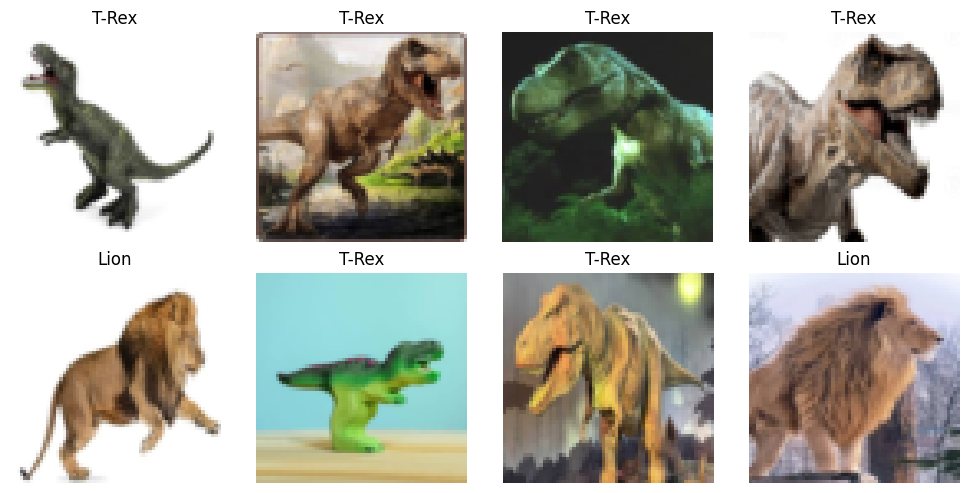

In [15]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for i, ax in enumerate(axes.flat):

    image = images[i].permute(1, 2, 0)

    ax.imshow(image)
    ax.set_title(train_dataset.classes[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [16]:
class TRexLionCNN(nn.Module):

    def __init__(self):
        super(TRexLionCNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),

            nn.Linear(128, 2)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


model = TRexLionCNN().to(device)

print(model)

TRexLionCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [17]:
LEARNING_RATE = 0.001
EPOCHS = 5
BATCH_SIZE = 32

print("Learning Rate:", LEARNING_RATE)
print("Epochs:", EPOCHS)
print("Batch Size:", BATCH_SIZE)

Learning Rate: 0.001
Epochs: 5
Batch Size: 32


In [18]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Loss Function: CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning Rate:", LEARNING_RATE)

Loss Function: CrossEntropyLoss
Optimizer: Adam
Learning Rate: 0.001


In [19]:
train_losses = []
train_accuracies = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/5] Loss: 0.6946 Accuracy: 50.00%
Epoch [2/5] Loss: 0.6796 Accuracy: 53.33%
Epoch [3/5] Loss: 0.6454 Accuracy: 63.33%
Epoch [4/5] Loss: 0.6314 Accuracy: 63.33%
Epoch [5/5] Loss: 0.6162 Accuracy: 70.00%


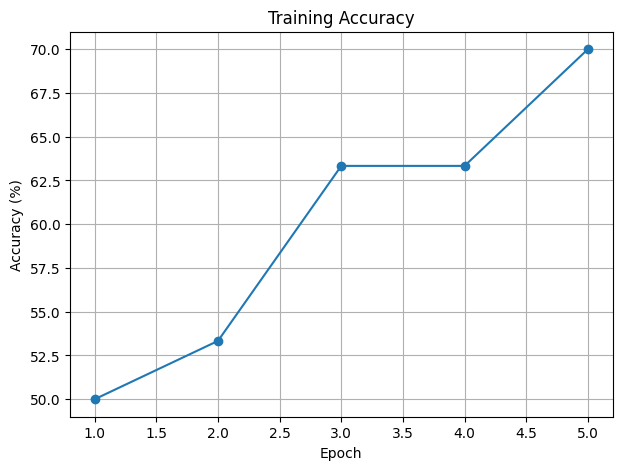

In [20]:
plt.figure(figsize=(7, 5))

plt.plot(
    range(1, EPOCHS + 1),
    train_accuracies,
    marker='o'
)

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)

plt.show()

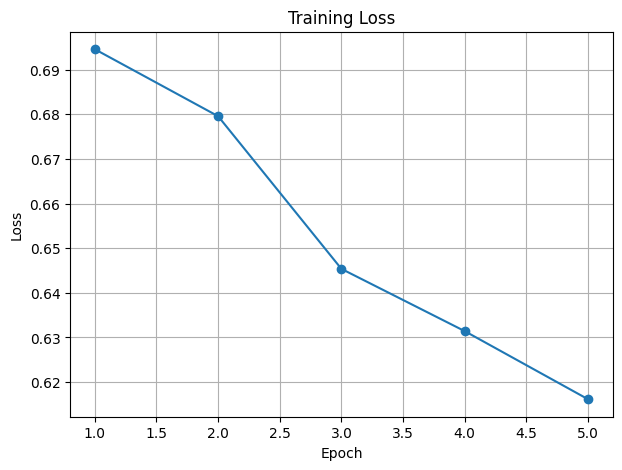

In [21]:

plt.figure(figsize=(7, 5))

plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker='o'
)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

In [22]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print("Total test images:", total)
print(f"Test Accuracy: {test_accuracy:.2f}%")

Total test images: 60
Test Accuracy: 81.67%


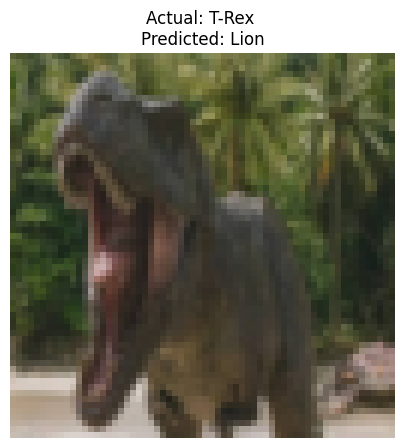

Actual: T-Rex 
Predicted: Lion


In [24]:
model.eval()

image, label = test_dataset[45]

image_input = image.unsqueeze(0).to(device)

with torch.no_grad():

    output = model(image_input)

    _, predicted = torch.max(output, 1)

actual_class = test_dataset.classes[label]
predicted_class = test_dataset.classes[predicted.item()]

plt.figure(figsize=(5, 5))

plt.imshow(image.permute(1, 2, 0))

plt.title(
    f"Actual: {actual_class}\n"
    f"Predicted: {predicted_class}"
)

plt.axis("off")
plt.show()

print("Actual:", actual_class)
print("Predicted:", predicted_class)

In [ ]:
model_path = "/content/drive/MyDrive/T_REX_LION_DATASET/trex_lion_cnn.pth"

torch.save(
    model.state_dict(),
    model_path
)

print("Model saved successfully.")
print(model_path)